# Smart-Kage Activity timing master plots

This notebook pulls every `activity_timing_stats.csv` file from cohort folders, combines them into one master table, and plots one metric per figure.

Each plot shows all ages and all genotypes in the same figure.

Expected CSV columns:

- `individual`
- `onset`
- `offset`
- `alpha`
- `rho`
- `phase_angle`
- `genotype`

The timing columns are assumed to be in minutes. The notebook converts onset, offset, alpha, and rho to hours for plotting. Phase angle is kept in minutes.


In [ ]:
# Figure styles
# Imports
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

{
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
}

FIG_W = 10
FIG_H = 8
WIDE_W = 16
WIDE_H = 7

AGE_ORDER = ["6m", "12m", "24m"]
GENO_ORDER = ["WT", "NLGF"]

GENO_COLORS = {
    "WT": "#34C6D3",          # teal
    "NLGF": "#F062B8",        # pink
    "APP1-em1BDS": "#FF8C00", # orange
    "NLF": "#9B5DE5",         # purple
}


def format_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(axis="both", direction="in", width=1.2, length=5, pad=6)
    ax.set_facecolor("white")
    return ax


def sem(x):
    x = pd.Series(pd.to_numeric(x, errors="coerce")).dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))


def ci95(x):
    s = sem(x)
    if pd.isna(s):
        return np.nan
    return 1.96 * s


## Set cohort folders

Edit the paths below if needed.

The notebook will search recursively inside each folder for:

`bodycenter_best_week/activity_timing_stats.csv`


In [4]:
# Main cohort folders
# Edit these paths to match your mounted drive/folders.

COHORT_ROOTS = {
    "6m_C1": Path("/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m"),
    "12m_C1": Path("/Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m"),
    "24m_C1": Path("/Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_Coh1"),
    "24m_C2": Path("/Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-Coh2"),
}
# optional: "6m_C2": Path("/Volumes/Aimi_SmrtKg/2026-01-Jan-Mar_NLGF6m_Coh2"),
OUTDIR = Path("/Volumes/Aimi_SmrtKg/activity_timing_master_outputs")
OUTDIR.mkdir(exist_ok=True, parents=True)

COHORT_ROOTS

{'6m_C1': PosixPath('/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m'),
 '12m_C1': PosixPath('/Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m'),
 '24m_C1': PosixPath('/Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_Coh1'),
 '24m_C2': PosixPath('/Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-Coh2')}

## Helper functions

These functions find CSV files, infer age from the cohort label/path, clean genotypes, and convert timing columns from minutes to hours where needed.


In [5]:
def infer_age_from_text(text):
    text = str(text).lower()
    if re.search(r"(^|[^0-9])6\s*m", text) or "nlgf6m" in text:
        return "6m"
    if re.search(r"(^|[^0-9])12\s*m", text) or "nlgf12m" in text:
        return "12m"
    if re.search(r"(^|[^0-9])24\s*m", text) or "nlgf24m" in text:
        return "24m"
    return "Unknown"


def clean_genotype(x):
    x = str(x).strip()
    replacements = {
        "APP-NLGF": "NLGF",
        "APP_NLGF": "NLGF",
        "APP NLGF": "NLGF",
        "APP1-em1BDS ": "APP1-em1BDS",
        "APP1": "APP1-em1BDS",
        "APP": "APP1-em1BDS",
    }
    return replacements.get(x, x)


def find_activity_csvs(cohort_roots):
    records = []
    for cohort, root in cohort_roots.items():
        root = Path(root)
        if not root.exists():
            print(f"Missing folder, skipped: {root}")
            continue

        hits = sorted(root.glob("**/bodycenter_best_week/activity_timing_stats.csv"))
        if not hits:
            # Fallback: in case the file is somewhere under bodycenter_best_week or named directly
            hits = sorted(root.glob("**/activity_timing_stats.csv"))

        if not hits:
            print(f"No activity_timing_stats.csv found under: {root}")
            continue

        for csv_path in hits:
            age = infer_age_from_text(cohort + " " + str(root))
            records.append({
                "cohort": cohort,
                "age": age,
                "csv_path": csv_path,
            })
            print(f"Found {cohort} | {age}: {csv_path}")

    return pd.DataFrame(records)


def read_one_activity_csv(row):
    df = pd.read_csv(row["csv_path"])
    df.columns = df.columns.str.strip()

    required = ["individual", "onset", "offset", "alpha", "rho", "phase_angle", "genotype"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {row['csv_path']}: {missing}")

    df = df[required].copy()
    df["cohort"] = row["cohort"]
    df["age"] = row["age"]
    df["source_file"] = str(row["csv_path"])
    df["genotype"] = df["genotype"].apply(clean_genotype)
    df["individual"] = df["individual"].astype(str).str.strip()

    for c in ["onset", "offset", "alpha", "rho", "phase_angle"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Convert minute-based metrics into plotting columns.
    df["onset_h"] = df["onset"] / 60.0
    df["offset_h"] = df["offset"] / 60.0
    df["alpha_h"] = df["alpha"] / 60.0
    df["rho_h"] = df["rho"] / 60.0
    df["phase_angle_min"] = df["phase_angle"]

    return df


def build_master_table(cohort_roots):
    found = find_activity_csvs(cohort_roots)
    if found.empty:
        raise FileNotFoundError("No activity_timing_stats.csv files were found. Check COHORT_ROOTS.")

    dfs = [read_one_activity_csv(row) for _, row in found.iterrows()]
    master = pd.concat(dfs, ignore_index=True)

    master["age"] = pd.Categorical(master["age"], categories=AGE_ORDER, ordered=True)
    master["genotype"] = pd.Categorical(master["genotype"], categories=GENO_ORDER, ordered=True)
    master = master.sort_values(["age", "cohort", "genotype", "individual"]).reset_index(drop=True)
    return master, found


## Load all cohort CSVs

Run this cell to build the combined master table.


In [6]:
master, found_files = build_master_table(COHORT_ROOTS)

print("Master table shape:", master.shape)
display(found_files)
display(master.head())

master.to_csv(OUTDIR / "activity_timing_master_table.csv", index=False)
print("Saved:", OUTDIR / "activity_timing_master_table.csv")

Found 6m_C1 | 6m: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/movement_analysis/bodycenter_best_week/activity_timing_stats.csv
Found 12m_C1 | 12m: /Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m/movement_analysis/bodycenter_best_week/activity_timing_stats.csv
Found 24m_C1 | 24m: /Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_Coh1/movement_analysis/bodycenter_best_week/activity_timing_stats.csv
Found 24m_C2 | 24m: /Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-Coh2/movement_analysis/bodycenter_best_week/activity_timing_stats.csv
Master table shape: (103, 15)


,cohort,age,csv_path
0,6m_C1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...
1,12m_C1,12m,/Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m/m...
2,24m_C1,24m,/Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_C...
3,24m_C2,24m,/Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-...


,individual,onset,offset,alpha,rho,phase_angle,genotype,cohort,age,source_file,onset_h,offset_h,alpha_h,rho_h,phase_angle_min
0,kage1,627.5,1252.5,625.0,815.0,57.5,WT,6m_C1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,10.458333,20.875000,10.416667,13.583333,57.5
1,kage11,597.5,1207.5,610.0,830.0,27.5,WT,6m_C1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,9.958333,20.125000,10.166667,13.833333,27.5
2,kage12,582.5,1167.5,585.0,855.0,12.5,WT,6m_C1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,9.708333,19.458333,9.750000,14.250000,12.5
3,kage17,572.5,1252.5,680.0,760.0,2.5,WT,6m_C1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,9.541667,20.875000,11.333333,12.666667,2.5
4,kage19,602.5,1292.5,690.0,750.0,32.5,WT,6m_C1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,10.041667,21.541667,11.500000,12.500000,32.5


Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/activity_timing_master_table.csv


## Check sample sizes

This is useful before plotting, because some cohorts may not contain every genotype.


In [7]:
n_table = (
    master
    .groupby(["age", "cohort", "genotype"], observed=True)["individual"]
    .nunique()
    .reset_index(name="n_mice")
)

display(n_table)
n_table.to_csv(OUTDIR / "activity_timing_sample_sizes.csv", index=False)


,age,cohort,genotype,n_mice
0,6m,6m_C1,WT,13
1,6m,6m_C1,NLGF,8
2,12m,12m_C1,WT,10
3,12m,12m_C1,NLGF,9
4,24m,24m_C1,WT,12
5,24m,24m_C1,NLGF,6
6,24m,24m_C2,WT,3
7,24m,24m_C2,NLGF,11


## Plotting functions

Each metric is plotted separately.

Plot structure:

- x-axis = age
- colours = genotype
- points = individual mice
- horizontal bar = mean
- error bar = 95% CI


In [8]:

from scipy.stats import shapiro as _sw, ttest_ind as _ttest_ind, mannwhitneyu as _mwu

def _thesis_stars(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

def _thesis_raw_test(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    y = pd.to_numeric(pd.Series(y), errors="coerce").dropna()
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx = (_sw(x).pvalue > 0.05) if len(x) >= 3 else False
    ny = (_sw(y).pvalue > 0.05) if len(y) >= 3 else False
    if nx and ny:
        return _ttest_ind(x, y, equal_var=False, nan_policy="omit").pvalue
    return _mwu(x, y, alternative="two-sided").pvalue

def _draw_bracket(ax, x1, x2, y, text, h, fontsize=18):
    if not text:
        return
    ax.plot([x1,x1,x2,x2], [y,y+h,y+h,y], color="black", lw=1.5, clip_on=False)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold", clip_on=False)

METRICS = {
    "onset_h": {
        "label": "Activity onset (h since 00:00)",
        "title": "Activity onset",
        "reference": 9.5,
        "reference_label": "light-cycle transition",
    },
    "offset_h": {
        "label": "Activity offset (h since 00:00)",
        "title": "Activity offset",
        "reference": 20.5,
        "reference_label": "light-cycle transition",
    },
    "phase_angle_min": {
        "label": "Phase angle (min)",
        "title": "Phase angle",
        "reference": 0,
        "reference_label": "light-cycle transition",
    },
    "alpha_h": {
        "label": r"$alpha$ - active duration (h)",
        "title": "Active duration",
        "reference": None,
        "reference_label": None,
    },
    "rho_h": {
        "label": r"$rho$ - rest duration (h)",
        "title": "Rest duration",
        "reference": None,
        "reference_label": None,
    },
}


def plot_metric_all_ages(
    df, metric, save=True, show_cohort_labels=False,
    jitter_width=0.06, dodge_width=0.22, seed=1,
):
    info = METRICS[metric]
    rng = np.random.default_rng(seed)
    plot_df = df.copy()
    plot_df = plot_df[plot_df["age"].isin(AGE_ORDER) & plot_df["genotype"].isin(GENO_ORDER)]
    plot_df[metric] = pd.to_numeric(plot_df[metric], errors="coerce")
    plot_df = plot_df.dropna(subset=[metric, "age", "genotype"])
    if plot_df.empty:
        print(f"No data for {metric}")
        return None

    fig, ax = plt.subplots(figsize=(16, 7))
    age_positions = {age: i for i, age in enumerate(AGE_ORDER)}
    present_genotypes = [g for g in GENO_ORDER if g in plot_df["genotype"].astype(str).unique()]
    raw_offsets = np.linspace(-dodge_width, dodge_width, max(len(present_genotypes),1))
    offsets = dict(zip(present_genotypes, raw_offsets))

    plotted_max = []
    for age in AGE_ORDER:
        for geno in present_genotypes:
            sub = plot_df[(plot_df["age"].astype(str)==age) & (plot_df["genotype"].astype(str)==geno)]
            values = pd.to_numeric(sub[metric], errors="coerce").dropna()
            if values.empty: continue
            xpos = age_positions[age] + offsets[geno]
            jitter = rng.normal(0, jitter_width, len(values))
            ax.scatter(np.full(len(values), xpos)+jitter, values, s=65,
                       color=GENO_COLORS.get(geno,"0.5"), alpha=0.72,
                       edgecolors="none", zorder=2)
            mean_val = values.mean()
            ci_val = ci95(values)
            ax.errorbar(xpos, mean_val, yerr=ci_val if not pd.isna(ci_val) else None,
                        fmt="none", ecolor=GENO_COLORS.get(geno,"0.5"),
                        elinewidth=2.5, capsize=9, capthick=2.5, zorder=3)
            ax.hlines(mean_val, xpos-0.09, xpos+0.09,
                      color=GENO_COLORS.get(geno,"0.5"), linewidth=3, zorder=4)
            plotted_max.extend(values.tolist())

    # RAW WT-vs-NLGF significance within each age
    if set(["WT","NLGF"]).issubset(offsets):
        ymin, ymax = np.nanmin(plotted_max), np.nanmax(plotted_max)
        span = max(ymax-ymin, 1)
        base = ymax + 0.08*span
        for i, age in enumerate(AGE_ORDER):
            wt = plot_df[(plot_df["age"]==age)&(plot_df["genotype"]=="WT")][metric]
            ng = plot_df[(plot_df["age"]==age)&(plot_df["genotype"]=="NLGF")][metric]
            p = _thesis_raw_test(wt, ng)
            star = _thesis_stars(p)
            if star:
                _draw_bracket(ax, i+offsets["WT"], i+offsets["NLGF"],
                              base, star, 0.03*span)
        # RAW age comparisons within genotype — show only significant
        level = base + 0.15*span
        for geno in present_genotypes:
            for a1,a2 in [("6m","12m"),("6m","24m"),("12m","24m")]:
                x = plot_df[(plot_df["age"]==a1)&(plot_df["genotype"]==geno)][metric]
                y = plot_df[(plot_df["age"]==a2)&(plot_df["genotype"]==geno)][metric]
                p = _thesis_raw_test(x,y)
                star = _thesis_stars(p)
                if star:
                    _draw_bracket(ax, age_positions[a1]+offsets[geno],
                                  age_positions[a2]+offsets[geno],
                                  level, star, 0.03*span)
                    level += 0.12*span
        ax.set_ylim(ax.get_ylim()[0], max(ax.get_ylim()[1], level+0.08*span))

    if info["reference"] is not None:
        ax.axhline(info["reference"], color="0.35", linestyle="--", linewidth=1.5, zorder=1)

    ax.set_xticks([age_positions[a] for a in AGE_ORDER])
    ax.set_xticklabels(AGE_ORDER)
    ax.set_xlabel("Age")
    ax.set_ylabel(info["label"])
    ax.set_title(info["title"])
    format_axes(ax)
    ax.set_xlim(-0.55, len(AGE_ORDER)-0.45)

    legend_handles = [
        Line2D([0],[0], marker="o", linestyle="none",
               markerfacecolor=GENO_COLORS[g], markeredgecolor="none",
               markersize=11, label=g) for g in present_genotypes
    ]
    ax.legend(handles=legend_handles, frameon=False,
              bbox_to_anchor=(1.02,1), loc="upper left")
    fig.tight_layout()

    if save:
        safe_name = metric.replace("_h","").replace("_min","")
        pdf_path = OUTDIR / f"THESIS_activity_timing_{safe_name}.pdf"
        png_path = OUTDIR / f"THESIS_activity_timing_{safe_name}.png"
        fig.savefig(pdf_path)
        fig.savefig(png_path, dpi=400)
        print("Saved:", pdf_path)
    return fig


## Generate one plot per metric

This will create:

- one onset plot
- one offset plot
- one phase angle plot
- one active duration plot
- one rest duration plot

Each figure includes all ages and all available genotypes.


Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/THESIS_activity_timing_onset.pdf


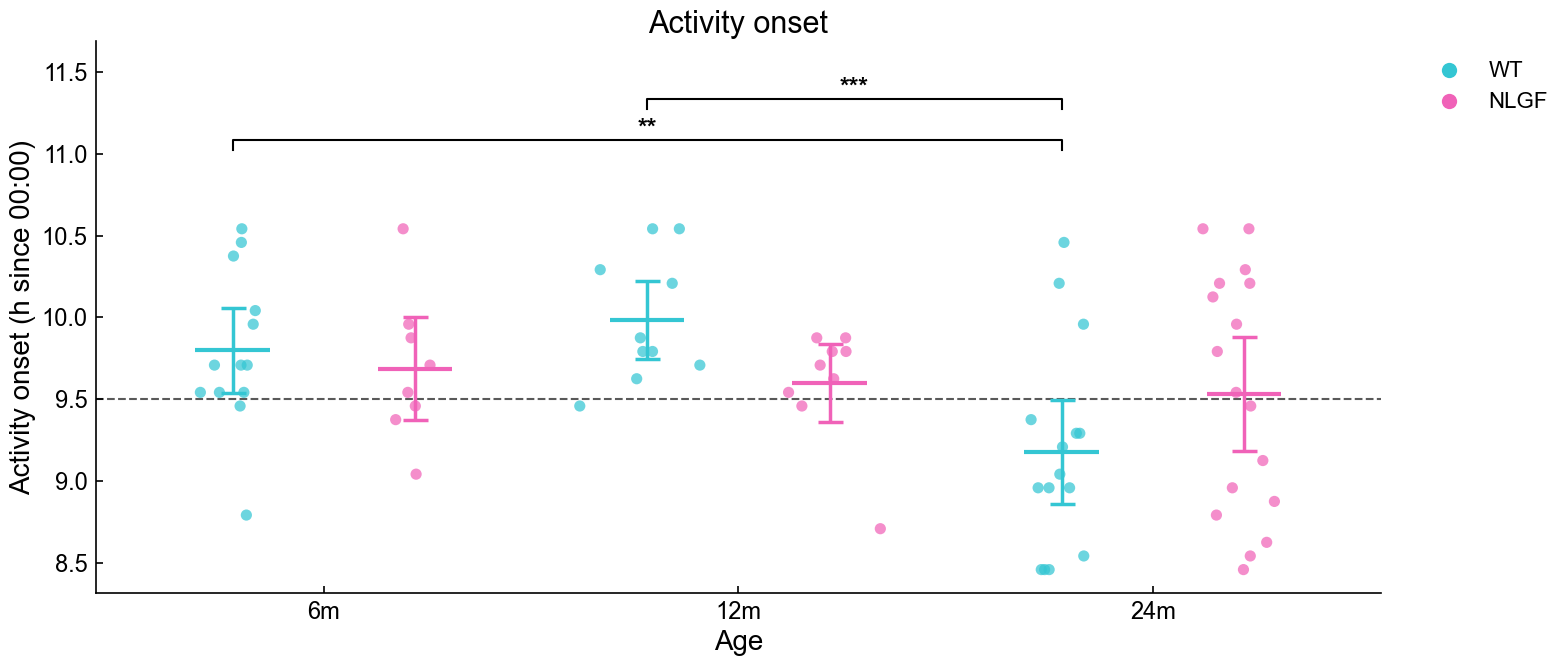

Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/THESIS_activity_timing_offset.pdf


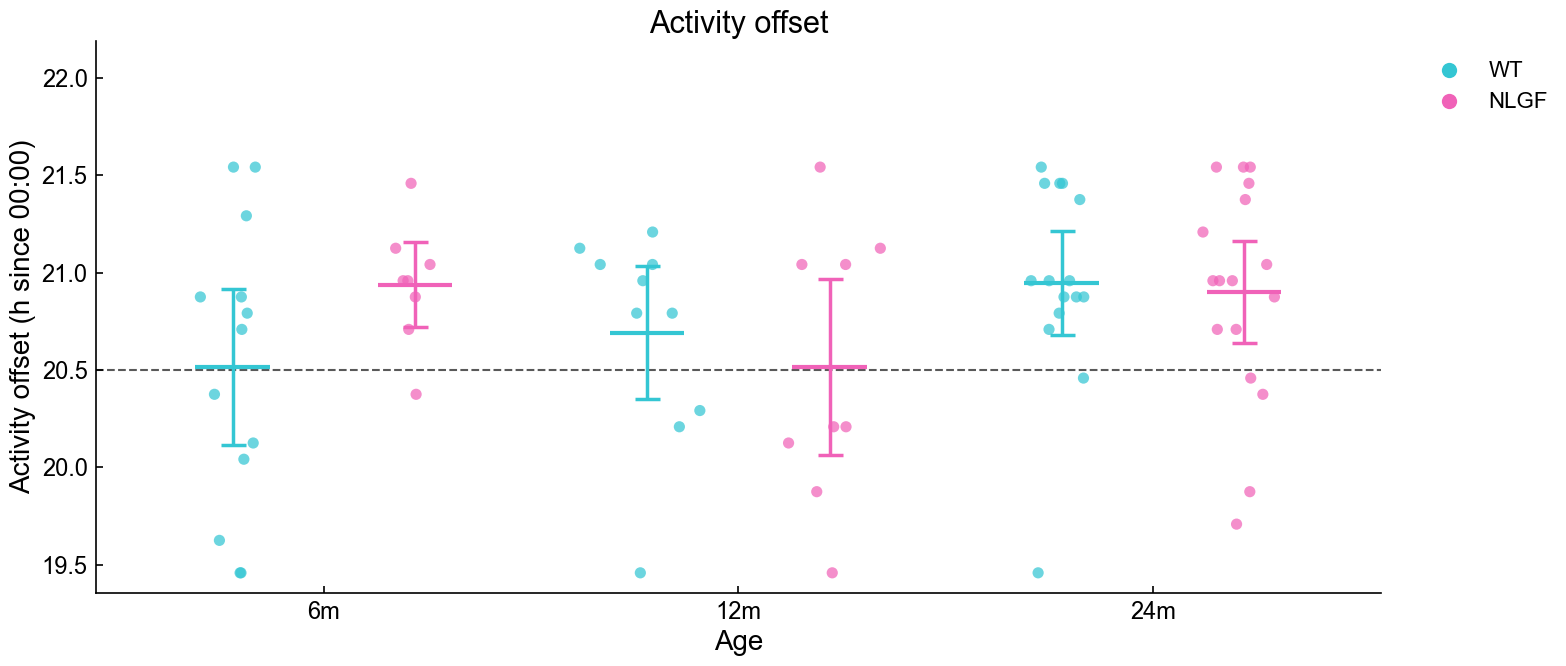

Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/THESIS_activity_timing_phase_angle.pdf


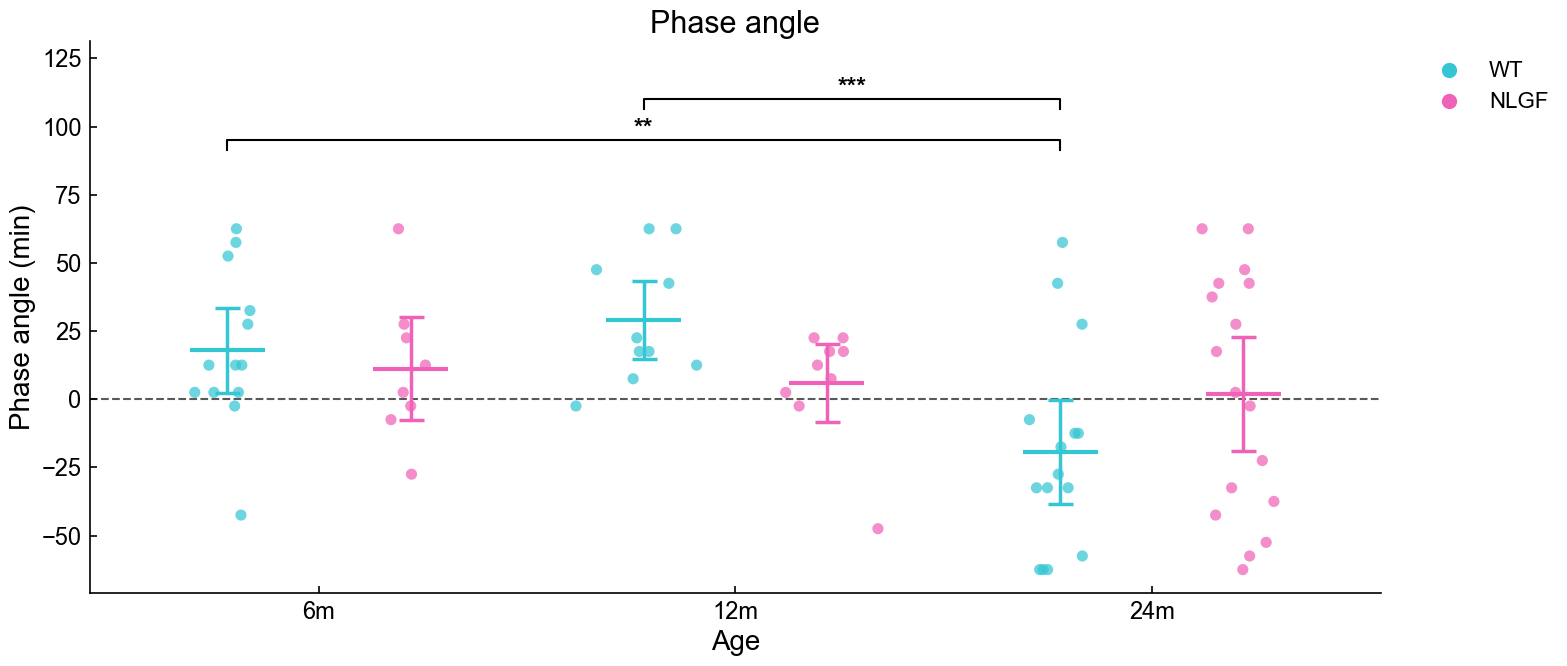

Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/THESIS_activity_timing_alpha.pdf


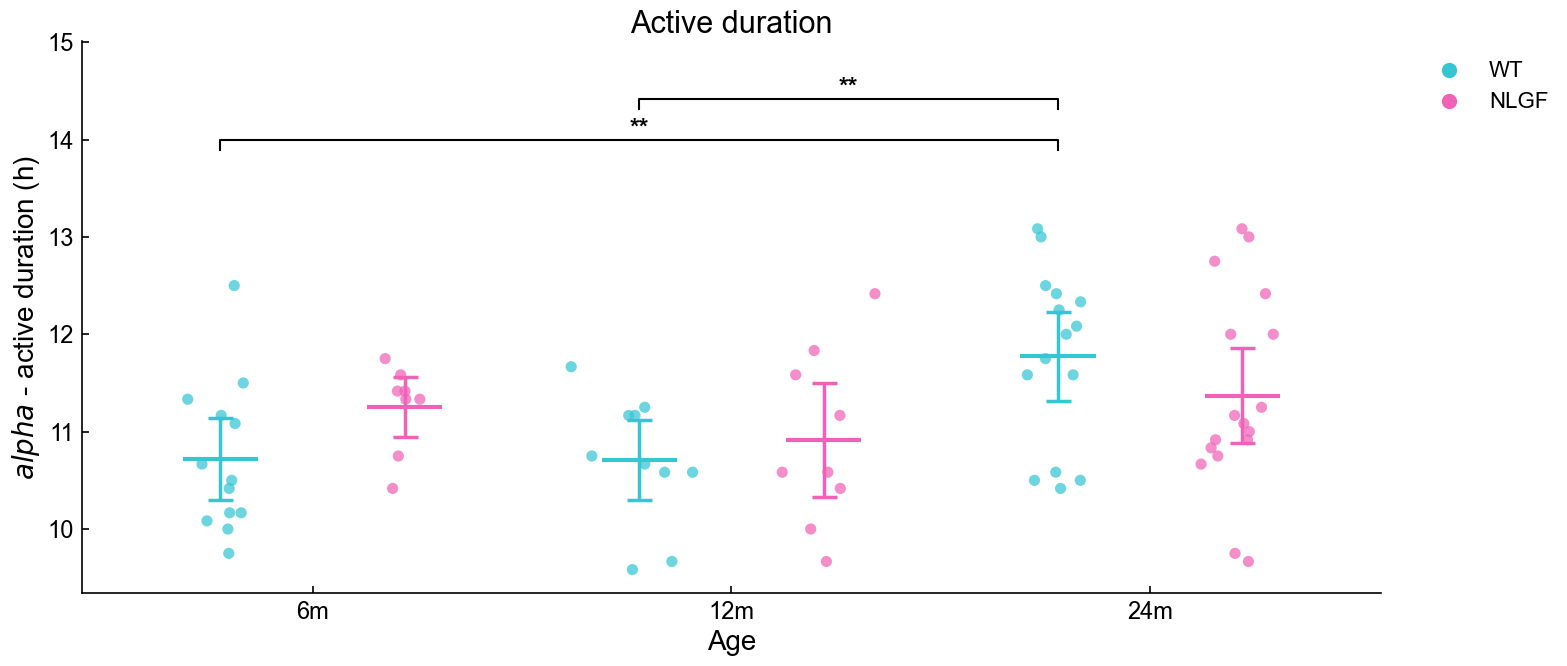

Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/THESIS_activity_timing_rho.pdf


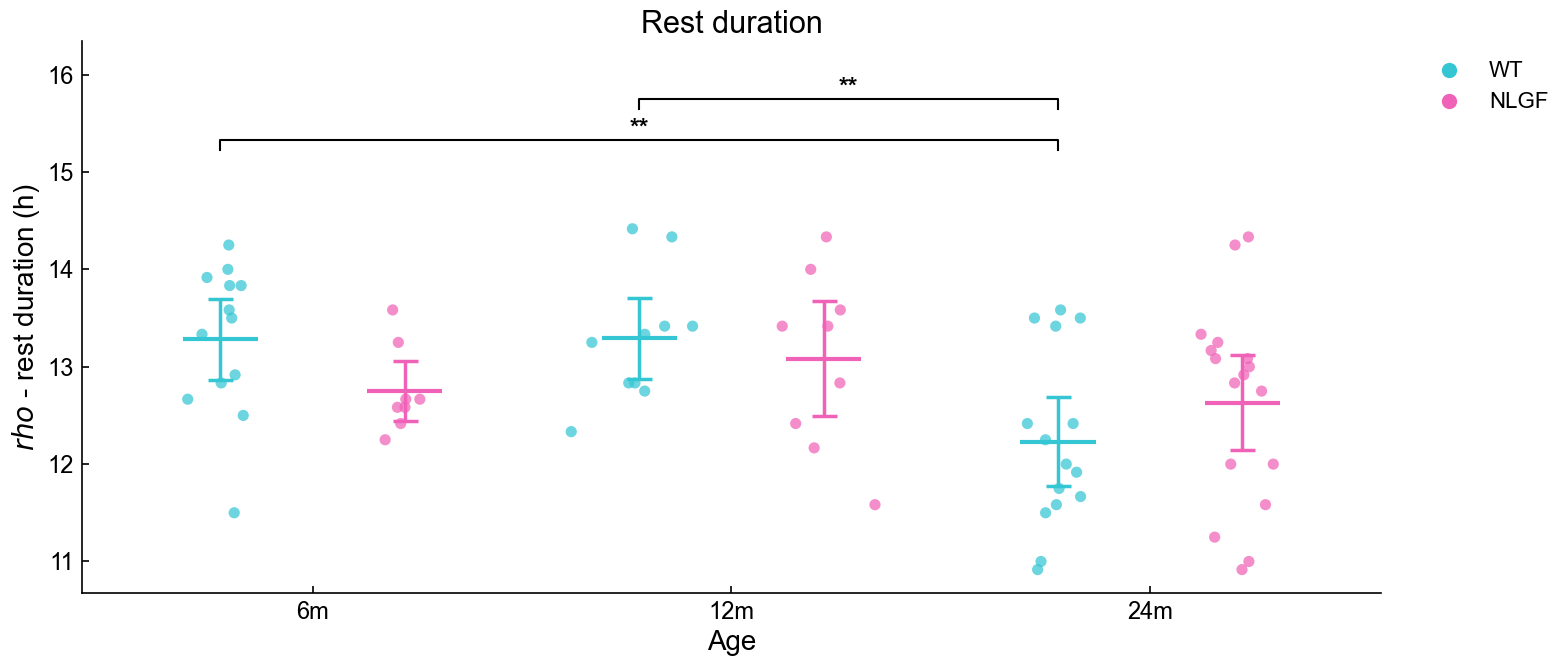

In [9]:
for metric in METRICS:
    fig = plot_metric_all_ages(master, metric, save=True)
    if fig is not None:
        plt.show()

## Optional: export summary statistics

This exports mean, SEM, 95% CI, standard deviation, and sample size for every age × genotype group.


In [10]:
summary_rows = []

for metric, info in METRICS.items():
    for (age, genotype), sub in master.groupby(["age", "genotype"], observed=True):
        values = pd.Series(pd.to_numeric(sub[metric], errors="coerce")).dropna()
        if values.empty:
            continue
        summary_rows.append({
            "metric": metric,
            "metric_label": info["label"],
            "age": age,
            "genotype": genotype,
            "n": len(values),
            "mean": values.mean(),
            "sd": values.std(ddof=1) if len(values) > 1 else np.nan,
            "sem": sem(values),
            "ci95": ci95(values),
        })

summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(OUTDIR / "activity_timing_summary_stats.csv", index=False)
print("Saved:", OUTDIR / "activity_timing_summary_stats.csv")

,metric,metric_label,age,genotype,n,mean,sd,sem,ci95
0,onset_h,Activity onset (h since 00:00),6m,WT,13,9.798077,0.479271,0.132926,0.260535
1,onset_h,Activity onset (h since 00:00),6m,NLGF,8,9.687500,0.451519,0.159636,0.312886
2,onset_h,Activity onset (h since 00:00),12m,WT,10,9.983333,0.385000,0.121748,0.238626
3,onset_h,Activity onset (h since 00:00),12m,NLGF,9,9.597222,0.363242,0.121081,0.237318
4,onset_h,Activity onset (h since 00:00),24m,WT,15,9.175000,0.626625,0.161794,0.317116
5,onset_h,Activity onset (h since 00:00),24m,NLGF,17,9.531863,0.731771,0.177480,0.347862
6,offset_h,Activity offset (h since 00:00),6m,WT,13,20.516026,0.736282,0.204208,0.400248
7,offset_h,Activity offset (h since 00:00),6m,NLGF,8,20.937500,0.314182,0.111080,0.217717
8,offset_h,Activity offset (h since 00:00),12m,WT,10,20.691667,0.548286,0.173383,0.339831
9,offset_h,Activity offset (h since 00:00),12m,NLGF,9,20.513889,0.693472,0.231157,0.453068


Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/activity_timing_summary_stats.csv


In [13]:
# =========================
# HELPER FUNCTIONS
# =========================

from pathlib import Path
Path(OUTDIR).mkdir(exist_ok=True)


def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def clean_values(data, metric):
    return pd.to_numeric(data[metric], errors="coerce").dropna()


def shapiro_safe(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan, np.nan, "too few values"
    if len(x) > 5000:
        x = x.sample(5000, random_state=1)
    stat, p = shapiro(x)
    return stat, p, "normal" if p > 0.05 else "not normal"


# =========================
# CLEAN DATA
# =========================

df = df.copy()
df = df[df[AGE_COL].isin(AGE_ORDER)]
df = df[df[GENO_COL].isin(GENO_ORDER)]

for metric in METRICS:
    if metric in df.columns:
        df[metric] = pd.to_numeric(df[metric], errors="coerce")

print("Data included:")
display(df.groupby([AGE_COL, GENO_COL]).size().reset_index(name="n"))

Data included:


/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_68010/351488017.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby([AGE_COL, GENO_COL]).size().reset_index(name="n"))


,age,genotype,n
0,6m,WT,13
1,6m,NLGF,8
2,12m,WT,10
3,12m,NLGF,9
4,24m,WT,15
5,24m,NLGF,17


In [14]:
# =========================
# 1. NORMALITY TESTS
# =========================

normality_results = []

for metric, metric_label in METRICS.items():
    if metric not in df.columns:
        print(f"Skipping missing metric: {metric}")
        continue

    for age in AGE_ORDER:
        for geno in GENO_ORDER:
            sub = df[(df[AGE_COL] == age) & (df[GENO_COL] == geno)]
            x = clean_values(sub, metric)

            W, p, result = shapiro_safe(x)

            normality_results.append({
                "metric": metric,
                "metric_label": metric_label,
                "age": age,
                "genotype": geno,
                "n": len(x),
                "shapiro_W": W,
                "shapiro_p": p,
                "normality": result,
            })

normality_df = pd.DataFrame(normality_results)
normality_df.to_csv(f"{OUTDIR}/normality_results.csv", index=False)

display(normality_df)


,metric,metric_label,age,genotype,n,shapiro_W,shapiro_p,normality
0,onset_h,Activity onset,6m,WT,13,0.931465,0.356143,normal
1,onset_h,Activity onset,6m,NLGF,8,0.966585,0.869949,normal
2,onset_h,Activity onset,12m,WT,10,0.911354,0.290425,normal
3,onset_h,Activity onset,12m,NLGF,9,0.745841,0.004852,not normal
4,onset_h,Activity onset,24m,WT,15,0.900123,0.095585,normal
5,onset_h,Activity onset,24m,NLGF,17,0.914745,0.120334,normal
6,phase_angle_min,Phase angle,6m,WT,13,0.931465,0.356143,normal
7,phase_angle_min,Phase angle,6m,NLGF,8,0.966585,0.869949,normal
8,phase_angle_min,Phase angle,12m,WT,10,0.911354,0.290425,normal
9,phase_angle_min,Phase angle,12m,NLGF,9,0.745841,0.004852,not normal


In [15]:
# =========================
# 2. WT VS NLGF WITHIN EACH AGE
# t-test if both normal
# Mann-Whitney if not normal
# =========================

wt_vs_nlgf_results = []

for metric, metric_label in METRICS.items():
    if metric not in df.columns:
        continue

    for age in AGE_ORDER:
        wt = clean_values(df[(df[AGE_COL] == age) & (df[GENO_COL] == "WT")], metric)
        nlgf = clean_values(df[(df[AGE_COL] == age) & (df[GENO_COL] == "NLGF")], metric)

        if len(wt) < 2 or len(nlgf) < 2:
            wt_vs_nlgf_results.append({
                "metric": metric,
                "metric_label": metric_label,
                "age": age,
                "comparison": "WT vs NLGF",
                "test": "not enough data",
                "statistic": np.nan,
                "p_value": np.nan,
                "stars": "NA",
                "WT_n": len(wt),
                "NLGF_n": len(nlgf),
                "WT_mean": wt.mean(),
                "NLGF_mean": nlgf.mean(),
            })
            continue

        wt_norm = normality_df.query(
            "metric == @metric and age == @age and genotype == 'WT'"
        )["shapiro_p"].iloc[0] > 0.05

        nlgf_norm = normality_df.query(
            "metric == @metric and age == @age and genotype == 'NLGF'"
        )["shapiro_p"].iloc[0] > 0.05

        if wt_norm and nlgf_norm:
            stat, p = ttest_ind(wt, nlgf, equal_var=False, nan_policy="omit")
            test_name = "Welch t-test"
        else:
            stat, p = mannwhitneyu(wt, nlgf, alternative="two-sided")
            test_name = "Mann-Whitney U"

        wt_vs_nlgf_results.append({
            "metric": metric,
            "metric_label": metric_label,
            "age": age,
            "comparison": "WT vs NLGF",
            "test": test_name,
            "statistic": stat,
            "p_value": p,
            "stars": p_to_stars(p),
            "WT_n": len(wt),
            "NLGF_n": len(nlgf),
            "WT_mean": wt.mean(),
            "NLGF_mean": nlgf.mean(),
            "WT_sem": wt.std(ddof=1) / np.sqrt(len(wt)) if len(wt) > 1 else np.nan,
            "NLGF_sem": nlgf.std(ddof=1) / np.sqrt(len(nlgf)) if len(nlgf) > 1 else np.nan,
        })

wt_vs_nlgf_df = pd.DataFrame(wt_vs_nlgf_results)
wt_vs_nlgf_df.to_csv(f"{OUTDIR}/WT_vs_NLGF_by_age.csv", index=False)

display(wt_vs_nlgf_df)


,metric,metric_label,age,comparison,test,statistic,p_value,stars,WT_n,NLGF_n,WT_mean,NLGF_mean,WT_sem,NLGF_sem
0,onset_h,Activity onset,6m,WT vs NLGF,Welch t-test,0.532304,0.601980,ns,13,8,9.798077,9.687500,0.132926,0.159636
1,onset_h,Activity onset,12m,WT vs NLGF,Mann-Whitney U,65.500000,0.099756,ns,10,9,9.983333,9.597222,0.121748,0.121081
2,onset_h,Activity onset,24m,WT vs NLGF,Welch t-test,-1.485941,0.147736,ns,15,17,9.175000,9.531863,0.161794,0.177480
3,phase_angle_min,Phase angle,6m,WT vs NLGF,Welch t-test,0.532304,0.601980,ns,13,8,17.884615,11.250000,7.975554,9.578156
4,phase_angle_min,Phase angle,12m,WT vs NLGF,Mann-Whitney U,65.500000,0.099756,ns,10,9,29.000000,5.833333,7.304869,7.264832
5,phase_angle_min,Phase angle,24m,WT vs NLGF,Welch t-test,-1.485941,0.147736,ns,15,17,-19.500000,1.911765,9.707631,10.648826
6,offset_h,Activity offset,6m,WT vs NLGF,Welch t-test,-1.813071,0.086988,ns,13,8,20.516026,20.937500,0.204208,0.111080
7,offset_h,Activity offset,12m,WT vs NLGF,Mann-Whitney U,52.000000,0.592840,ns,10,9,20.691667,20.513889,0.173383,0.231157
8,offset_h,Activity offset,24m,WT vs NLGF,Mann-Whitney U,128.000000,1.000000,ns,15,17,20.947222,20.899510,0.135807,0.134402
9,alpha_h,Active duration,6m,WT vs NLGF,Welch t-test,-2.009580,0.058916,ns,13,8,10.717949,11.250000,0.213408,0.156696


In [ ]:
# =========================
# 3. AGE EFFECT WITHIN EACH GENOTYPE
# 6m vs 12m vs 24m
# =========================

age_effect_results = []
pairwise_age_results = []

for metric, metric_label in METRICS.items():
    if metric not in df.columns:
        continue

    for geno in GENO_ORDER:
        groups = []
        group_names = []

        for age in AGE_ORDER:
            x = clean_values(
                df[(df[AGE_COL] == age) & (df[GENO_COL] == geno)],
                metric
            )
            if len(x) >= 2:
                groups.append(x)
                group_names.append(age)

        if len(groups) < 2:
            continue

        normal_flags = []
        for age in group_names:
            p_norm = normality_df.query(
                "metric == @metric and age == @age and genotype == @geno"
            )["shapiro_p"].iloc[0]
            normal_flags.append(pd.notna(p_norm) and p_norm > 0.05)

        all_normal = all(normal_flags)

        if all_normal:
            stat, p = f_oneway(*groups)
            test_name = "One-way ANOVA"
        else:
            stat, p = kruskal(*groups)
            test_name = "Kruskal-Wallis"

        age_effect_results.append({
            "metric": metric,
            "metric_label": metric_label,
            "genotype": geno,
            "comparison": "6m vs 12m vs 24m",
            "test": test_name,
            "statistic": stat,
            "p_value": p,
            "stars": p_to_stars(p),
        })

        # Pairwise age comparisons: RAW p-values only, no Holm/FDR adjustment.
        for i in range(len(group_names)):
            for j in range(i + 1, len(group_names)):
                age1 = group_names[i]
                age2 = group_names[j]
                x1 = groups[i]
                x2 = groups[j]

                # Decide normality separately for the two groups being compared.
                p1 = normality_df.query(
                    "metric == @metric and age == @age1 and genotype == @geno"
                )["shapiro_p"].iloc[0]
                p2 = normality_df.query(
                    "metric == @metric and age == @age2 and genotype == @geno"
                )["shapiro_p"].iloc[0]

                pair_normal = (
                    pd.notna(p1) and p1 > 0.05
                    and pd.notna(p2) and p2 > 0.05
                )

                if pair_normal:
                    pair_stat, pair_p = ttest_ind(
                        x1, x2, equal_var=False, nan_policy="omit"
                    )
                    pair_test = "Welch t-test"
                else:
                    pair_stat, pair_p = mannwhitneyu(
                        x1, x2, alternative="two-sided"
                    )
                    pair_test = "Mann-Whitney U"

                pairwise_age_results.append({
                    "metric": metric,
                    "metric_label": metric_label,
                    "genotype": geno,
                    "comparison": f"{age1} vs {age2}",
                    "test": pair_test,
                    "statistic": pair_stat,
                    "p_value": pair_p,
                    "stars": p_to_stars(pair_p),
                })

age_effect_df = pd.DataFrame(age_effect_results)
pairwise_age_df = pd.DataFrame(pairwise_age_results)

age_effect_df.to_csv(f"{OUTDIR}/age_effect_within_genotype_unadjusted.csv", index=False)
pairwise_age_df.to_csv(f"{OUTDIR}/pairwise_age_comparisons_unadjusted.csv", index=False)

display(age_effect_df)
display(pairwise_age_df)

print("Saved RAW/UNADJUSTED age-effect statistics.")


,metric,metric_label,genotype,comparison,test,statistic,p_value,stars
0,onset_h,Activity onset,WT,6m vs 12m vs 24m,One-way ANOVA,8.558362,0.000942,***
1,onset_h,Activity onset,NLGF,6m vs 12m vs 24m,Kruskal-Wallis,0.084537,0.958613,ns
2,phase_angle_min,Phase angle,WT,6m vs 12m vs 24m,One-way ANOVA,8.558362,0.000942,***
3,phase_angle_min,Phase angle,NLGF,6m vs 12m vs 24m,Kruskal-Wallis,0.084537,0.958613,ns
4,offset_h,Activity offset,WT,6m vs 12m vs 24m,Kruskal-Wallis,2.999240,0.223215,ns
5,offset_h,Activity offset,NLGF,6m vs 12m vs 24m,One-way ANOVA,1.730038,0.193957,ns
6,alpha_h,Active duration,WT,6m vs 12m vs 24m,One-way ANOVA,7.895609,0.001479,**
7,alpha_h,Active duration,NLGF,6m vs 12m vs 24m,One-way ANOVA,0.759436,0.476438,ns
8,rho_h,Rest duration,WT,6m vs 12m vs 24m,One-way ANOVA,7.895609,0.001479,**
9,rho_h,Rest duration,NLGF,6m vs 12m vs 24m,One-way ANOVA,0.759436,0.476438,ns


,metric,metric_label,genotype,comparison,test,statistic,p_value,stars
0,onset_h,Activity onset,WT,6m vs 12m,Welch t-test,-1.027747,0.315798,ns
1,onset_h,Activity onset,WT,6m vs 24m,Welch t-test,2.975596,0.006299,**
2,onset_h,Activity onset,WT,12m vs 24m,Welch t-test,3.992085,0.000577,***
3,onset_h,Activity onset,NLGF,6m vs 12m,Mann-Whitney U,36.500000,1.000000,ns
4,onset_h,Activity onset,NLGF,6m vs 24m,Welch t-test,0.651990,0.521488,ns
5,onset_h,Activity onset,NLGF,12m vs 24m,Mann-Whitney U,76.000000,1.000000,ns
6,phase_angle_min,Phase angle,WT,6m vs 12m,Welch t-test,-1.027747,0.315798,ns
7,phase_angle_min,Phase angle,WT,6m vs 24m,Welch t-test,2.975596,0.006299,**
8,phase_angle_min,Phase angle,WT,12m vs 24m,Welch t-test,3.992085,0.000577,***
9,phase_angle_min,Phase angle,NLGF,6m vs 12m,Mann-Whitney U,36.500000,1.000000,ns


Saved RAW/UNADJUSTED age-effect statistics.


In [17]:
# =========================
# 4. SAVE COMBINED UNADJUSTED OUTPUT
# =========================

combined_parts = []

if not wt_vs_nlgf_df.empty:
    combined_parts.append(
        wt_vs_nlgf_df.assign(analysis_type="WT_vs_NLGF_within_age")
    )

if not age_effect_df.empty:
    combined_parts.append(
        age_effect_df.assign(analysis_type="Overall_age_effect_within_genotype")
    )

if not pairwise_age_df.empty:
    combined_parts.append(
        pairwise_age_df.assign(analysis_type="Pairwise_age_within_genotype")
    )

if combined_parts:
    combined_stats = pd.concat(combined_parts, ignore_index=True, sort=False)
    combined_stats.to_csv(
        f"{OUTDIR}/activity_timing_all_unadjusted_statistics.csv",
        index=False
    )
    display(combined_stats)
    print(
        "Saved:",
        f"{OUTDIR}/activity_timing_all_unadjusted_statistics.csv"
    )


,metric,metric_label,age,comparison,test,statistic,p_value,stars,WT_n,NLGF_n,WT_mean,NLGF_mean,WT_sem,NLGF_sem,analysis_type,genotype
0,onset_h,Activity onset,6m,WT vs NLGF,Welch t-test,0.532304,0.601980,ns,13.0,8.0,9.798077,9.687500,0.132926,0.159636,WT_vs_NLGF_within_age,NaN
1,onset_h,Activity onset,12m,WT vs NLGF,Mann-Whitney U,65.500000,0.099756,ns,10.0,9.0,9.983333,9.597222,0.121748,0.121081,WT_vs_NLGF_within_age,NaN
2,onset_h,Activity onset,24m,WT vs NLGF,Welch t-test,-1.485941,0.147736,ns,15.0,17.0,9.175000,9.531863,0.161794,0.177480,WT_vs_NLGF_within_age,NaN
3,phase_angle_min,Phase angle,6m,WT vs NLGF,Welch t-test,0.532304,0.601980,ns,13.0,8.0,17.884615,11.250000,7.975554,9.578156,WT_vs_NLGF_within_age,NaN
4,phase_angle_min,Phase angle,12m,WT vs NLGF,Mann-Whitney U,65.500000,0.099756,ns,10.0,9.0,29.000000,5.833333,7.304869,7.264832,WT_vs_NLGF_within_age,NaN
5,phase_angle_min,Phase angle,24m,WT vs NLGF,Welch t-test,-1.485941,0.147736,ns,15.0,17.0,-19.500000,1.911765,9.707631,10.648826,WT_vs_NLGF_within_age,NaN
6,offset_h,Activity offset,6m,WT vs NLGF,Welch t-test,-1.813071,0.086988,ns,13.0,8.0,20.516026,20.937500,0.204208,0.111080,WT_vs_NLGF_within_age,NaN
7,offset_h,Activity offset,12m,WT vs NLGF,Mann-Whitney U,52.000000,0.592840,ns,10.0,9.0,20.691667,20.513889,0.173383,0.231157,WT_vs_NLGF_within_age,NaN
8,offset_h,Activity offset,24m,WT vs NLGF,Mann-Whitney U,128.000000,1.000000,ns,15.0,17.0,20.947222,20.899510,0.135807,0.134402,WT_vs_NLGF_within_age,NaN
9,alpha_h,Active duration,6m,WT vs NLGF,Welch t-test,-2.009580,0.058916,ns,13.0,8.0,10.717949,11.250000,0.213408,0.156696,WT_vs_NLGF_within_age,NaN


Saved: /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/statistics_results/activity_timing_all_unadjusted_statistics.csv


## Age × Genotype statistics 

For each activity-timing outcome, this section fits an ordinary two-way ANOVA with **Age**, **Genotype**, and the **Age × Genotype interaction**. It also tests ANOVA residual normality using Shapiro–Wilk. 


In [18]:
# =========================
# 5. TWO-WAY ANOVA: AGE × GENOTYPE
# RAW / UNADJUSTED P VALUES ONLY
# =========================

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

two_way_results = []
residual_normality_results = []

for metric, metric_label in METRICS.items():
    if metric not in df.columns:
        continue

    model_df = df[[AGE_COL, GENO_COL, metric]].copy()
    model_df[metric] = pd.to_numeric(model_df[metric], errors="coerce")
    model_df = model_df.dropna(subset=[AGE_COL, GENO_COL, metric])

    # Keep only the requested age/genotype groups.
    model_df = model_df[
        model_df[AGE_COL].isin(AGE_ORDER)
        & model_df[GENO_COL].isin(GENO_ORDER)
    ].copy()

    if model_df.empty:
        continue

    # Explicit categorical ordering.
    model_df[AGE_COL] = pd.Categorical(
        model_df[AGE_COL], categories=AGE_ORDER, ordered=True
    )
    model_df[GENO_COL] = pd.Categorical(
        model_df[GENO_COL], categories=GENO_ORDER, ordered=True
    )

    # Ordinary two-way ANOVA with interaction.
    # Type II sums of squares are used for the main effects and interaction.
    formula = f'Q("{metric}") ~ C({AGE_COL}) * C({GENO_COL})'
    model = smf.ols(formula, data=model_df).fit()
    aov = anova_lm(model, typ=2)

    effect_name_map = {
        f"C({AGE_COL})": "Age",
        f"C({GENO_COL})": "Genotype",
        f"C({AGE_COL}):C({GENO_COL})": "Age x Genotype",
        "Residual": "Residual",
    }

    for source, row in aov.iterrows():
        if source == "Residual":
            continue

        F_value = row.get("F", np.nan)
        p_value = row.get("PR(>F)", np.nan)
        df_num = row.get("df", np.nan)
        df_den = aov.loc["Residual", "df"] if "Residual" in aov.index else np.nan

        two_way_results.append({
            "metric": metric,
            "metric_label": metric_label,
            "effect": effect_name_map.get(source, source),
            "df_num": df_num,
            "df_den": df_den,
            "F": F_value,
            "p_value": p_value,
            "stars": p_to_stars(p_value),
            "n_total": len(model_df),
        })

    # Residual normality for the fitted ANOVA.
    resid = pd.Series(model.resid).dropna()
    if len(resid) >= 3:
        W, p_resid = shapiro(resid)
        resid_result = "normal" if p_resid > 0.05 else "not normal"
    else:
        W, p_resid, resid_result = np.nan, np.nan, "too few values"

    residual_normality_results.append({
        "metric": metric,
        "metric_label": metric_label,
        "n_residuals": len(resid),
        "shapiro_W": W,
        "shapiro_p": p_resid,
        "residual_normality": resid_result,
    })

two_way_anova_df = pd.DataFrame(two_way_results)
two_way_residual_normality_df = pd.DataFrame(residual_normality_results)

two_way_anova_df.to_csv(
    f"{OUTDIR}/two_way_ANOVA_Age_x_Genotype_unadjusted.csv",
    index=False
)
two_way_residual_normality_df.to_csv(
    f"{OUTDIR}/two_way_ANOVA_residual_normality.csv",
    index=False
)

display(two_way_anova_df)
display(two_way_residual_normality_df)

print("Saved:")
print(f"  {OUTDIR}/two_way_ANOVA_Age_x_Genotype_unadjusted.csv")
print(f"  {OUTDIR}/two_way_ANOVA_residual_normality.csv")


,metric,metric_label,effect,df_num,df_den,F,p_value,stars,n_total
0,onset_h,Activity onset,Age,2.0,66.0,4.881719,0.010539,*,72
1,onset_h,Activity onset,Genotype,1.0,66.0,0.039528,0.843017,ns,72
2,onset_h,Activity onset,Age x Genotype,2.0,66.0,2.828920,0.066259,ns,72
3,phase_angle_min,Phase angle,Age,2.0,66.0,4.881719,0.010539,*,72
4,phase_angle_min,Phase angle,Genotype,1.0,66.0,0.039528,0.843017,ns,72
5,phase_angle_min,Phase angle,Age x Genotype,2.0,66.0,2.828920,0.066259,ns,72
6,offset_h,Activity offset,Age,2.0,66.0,2.002020,0.143182,ns,72
7,offset_h,Activity offset,Genotype,1.0,66.0,0.124095,0.725758,ns,72
8,offset_h,Activity offset,Age x Genotype,2.0,66.0,1.471992,0.236902,ns,72
9,alpha_h,Active duration,Age,2.0,66.0,5.930634,0.004279,**,72


,metric,metric_label,n_residuals,shapiro_W,shapiro_p,residual_normality
0,onset_h,Activity onset,72,0.984058,0.496561,normal
1,phase_angle_min,Phase angle,72,0.984058,0.496561,normal
2,offset_h,Activity offset,72,0.964594,0.040349,not normal
3,alpha_h,Active duration,72,0.988073,0.733442,normal
4,rho_h,Rest duration,72,0.988073,0.733442,normal


Saved:
  /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/statistics_results/two_way_ANOVA_Age_x_Genotype_unadjusted.csv
  /Volumes/Aimi_SmrtKg/activity_timing_master_outputs/statistics_results/two_way_ANOVA_residual_normality.csv


In [ ]:
# =========================
# 6. STATS SUMMARY 
# =========================

print("UNADJUSTED WT vs NLGF comparisons within age:")
display(
    wt_vs_nlgf_df[
        [
            "metric_label", "age", "test", "statistic",
            "p_value", "stars", "WT_n", "NLGF_n"
        ]
    ]
)

print("\nAGE × GENOTYPE TWO-WAY ANOVA:")
display(
    two_way_anova_df[
        [
            "metric_label", "effect", "df_num", "df_den",
            "F", "p_value", "stars", "n_total"
        ]
    ]
)

print("\nANOVA residual normality:")
display(two_way_residual_normality_df)

print(
    "\nIMPORTANT: All p-values in this final section are RAW/UNADJUSTED. "
    "No Holm or FDR correction has been applied."
)


UNADJUSTED WT vs NLGF comparisons within age:


,metric_label,age,test,statistic,p_value,stars,WT_n,NLGF_n
0,Activity onset,6m,Welch t-test,0.532304,0.601980,ns,13,8
1,Activity onset,12m,Mann-Whitney U,65.500000,0.099756,ns,10,9
2,Activity onset,24m,Welch t-test,-1.485941,0.147736,ns,15,17
3,Phase angle,6m,Welch t-test,0.532304,0.601980,ns,13,8
4,Phase angle,12m,Mann-Whitney U,65.500000,0.099756,ns,10,9
5,Phase angle,24m,Welch t-test,-1.485941,0.147736,ns,15,17
6,Activity offset,6m,Welch t-test,-1.813071,0.086988,ns,13,8
7,Activity offset,12m,Mann-Whitney U,52.000000,0.592840,ns,10,9
8,Activity offset,24m,Mann-Whitney U,128.000000,1.000000,ns,15,17
9,Active duration,6m,Welch t-test,-2.009580,0.058916,ns,13,8



AGE × GENOTYPE TWO-WAY ANOVA:


,metric_label,effect,df_num,df_den,F,p_value,stars,n_total
0,Activity onset,Age,2.0,66.0,4.881719,0.010539,*,72
1,Activity onset,Genotype,1.0,66.0,0.039528,0.843017,ns,72
2,Activity onset,Age x Genotype,2.0,66.0,2.828920,0.066259,ns,72
3,Phase angle,Age,2.0,66.0,4.881719,0.010539,*,72
4,Phase angle,Genotype,1.0,66.0,0.039528,0.843017,ns,72
5,Phase angle,Age x Genotype,2.0,66.0,2.828920,0.066259,ns,72
6,Activity offset,Age,2.0,66.0,2.002020,0.143182,ns,72
7,Activity offset,Genotype,1.0,66.0,0.124095,0.725758,ns,72
8,Activity offset,Age x Genotype,2.0,66.0,1.471992,0.236902,ns,72
9,Active duration,Age,2.0,66.0,5.930634,0.004279,**,72



ANOVA residual normality:


,metric,metric_label,n_residuals,shapiro_W,shapiro_p,residual_normality
0,onset_h,Activity onset,72,0.984058,0.496561,normal
1,phase_angle_min,Phase angle,72,0.984058,0.496561,normal
2,offset_h,Activity offset,72,0.964594,0.040349,not normal
3,alpha_h,Active duration,72,0.988073,0.733442,normal
4,rho_h,Rest duration,72,0.988073,0.733442,normal



IMPORTANT: All p-values in this final section are RAW/UNADJUSTED. No Holm or FDR correction has been applied.
